Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load the DataSet

In [ ]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

In [ ]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [ ]:
df.shape

(250000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [ ]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [ ]:
df.describe(include='object')

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


In [ ]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns
num_col

Index(['experience_years', 'skills_count', 'certifications', 'salary'], dtype='object')

In [ ]:
cat_col = df.select_dtypes(include=['object']).columns
cat_col

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')

# Unique Values in each column

In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

job_title: 12
experience_years: 21
education_level: 5
skills_count: 19
industry: 10
company_size: 5
location: 10
remote_work: 3
certifications: 6
salary: 118956


Hist Plot for Numerical Columns

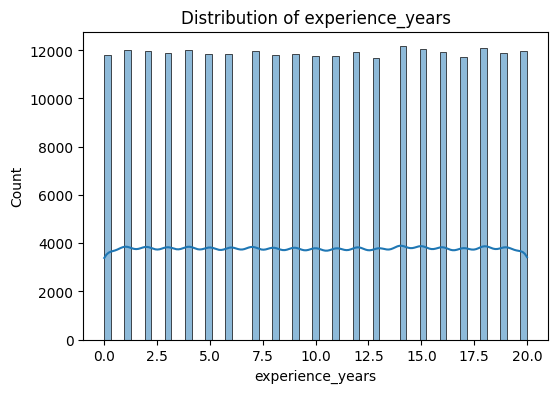

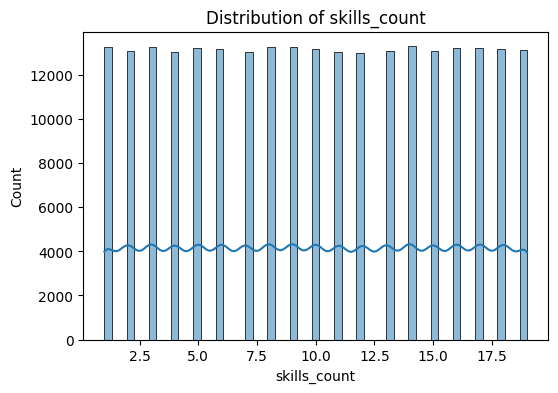

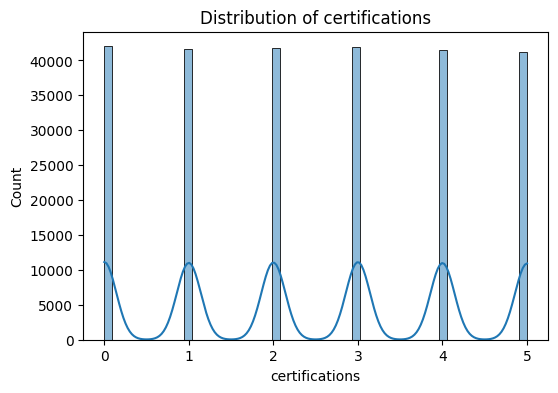

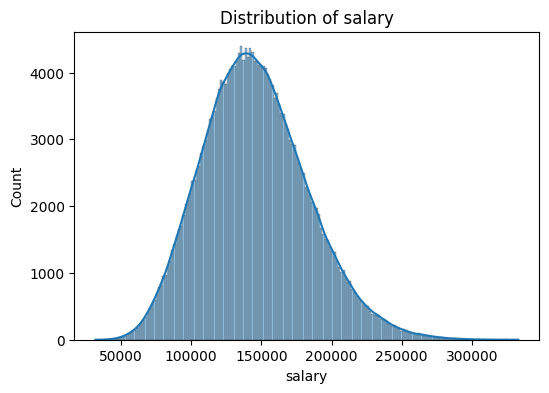

In [ ]:
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Count Plot for all Categorical Columns

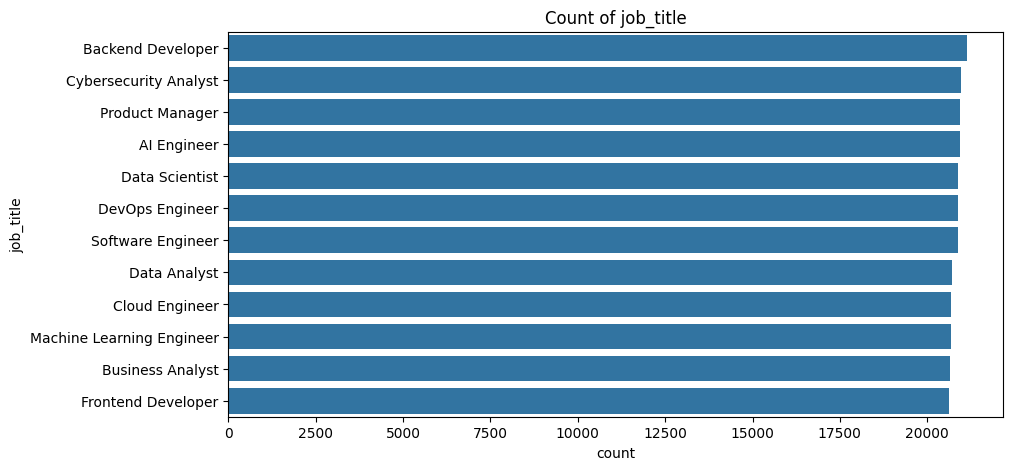

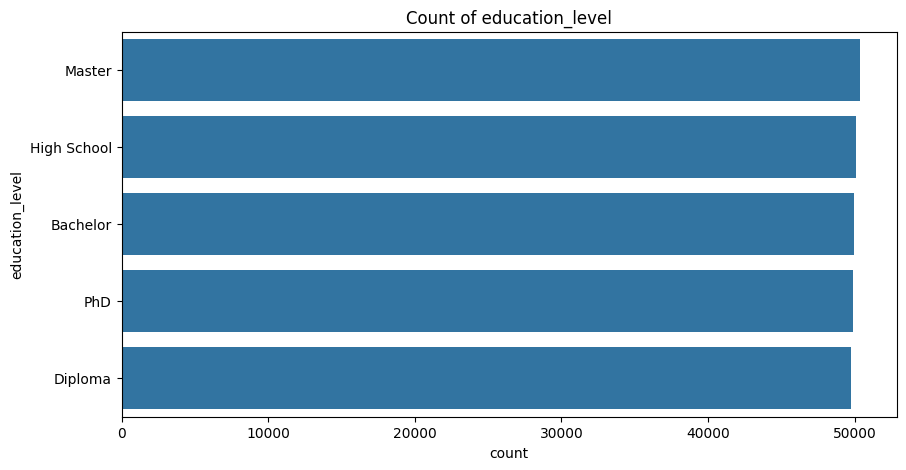

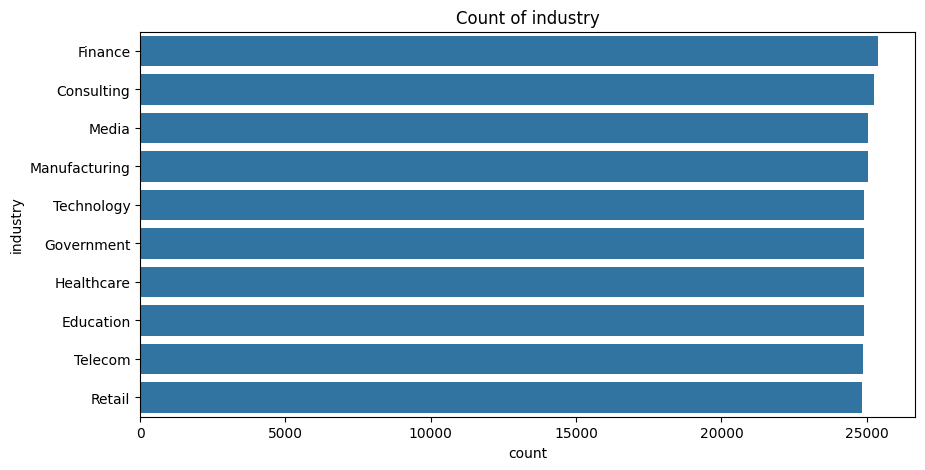

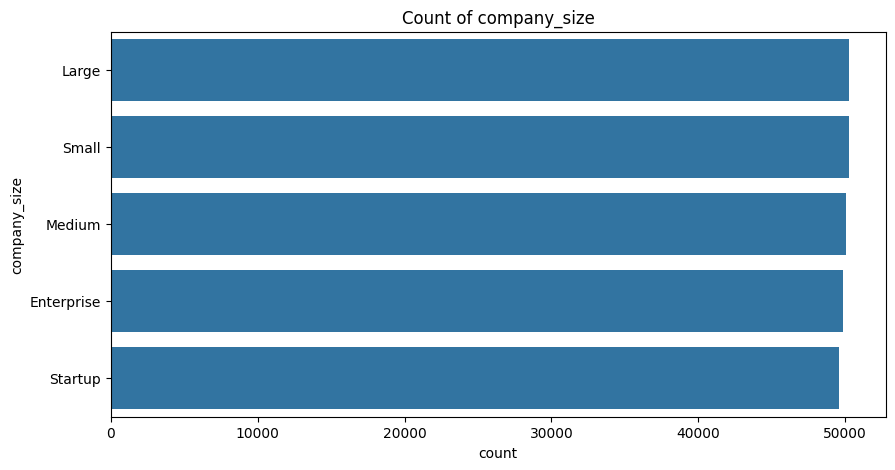

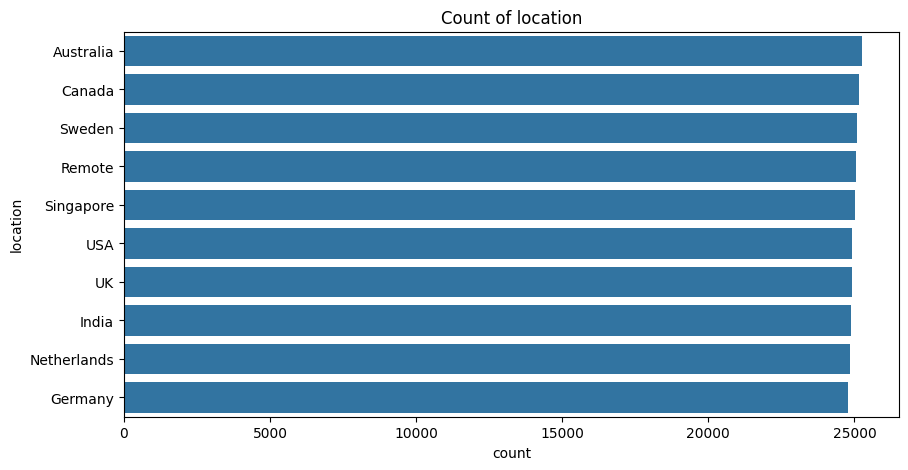

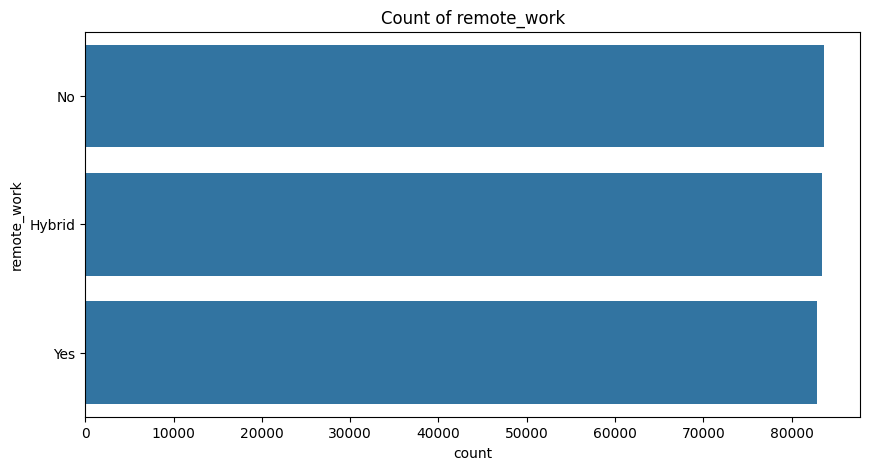

In [ ]:
for col in cat_col:
    plt.figure(figsize=(10,5))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.show()

Target Column

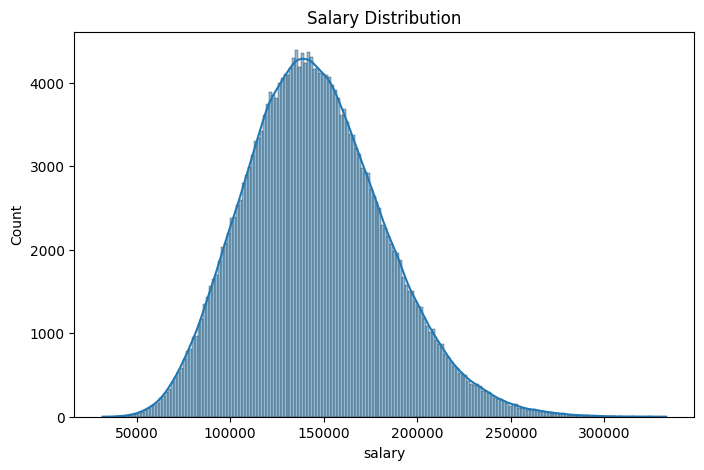

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

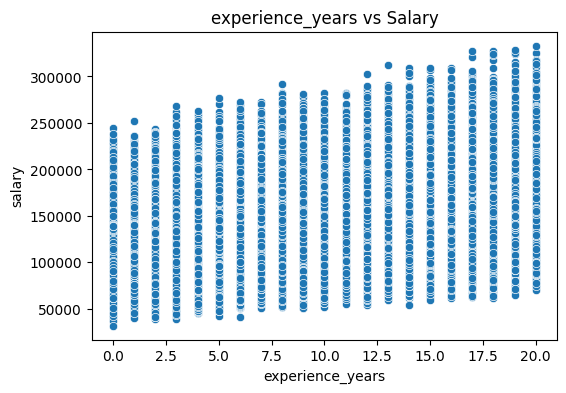

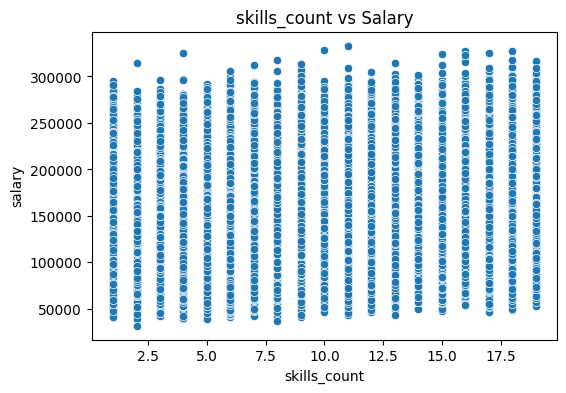

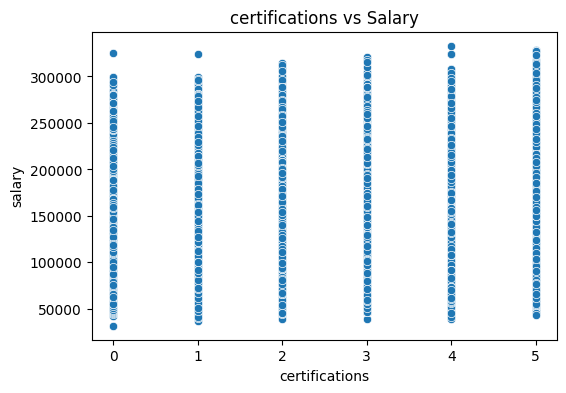

In [ ]:
num_features = ['experience_years', 'skills_count', 'certifications']

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['salary'])
    plt.title(f"{col} vs Salary")
    plt.show()

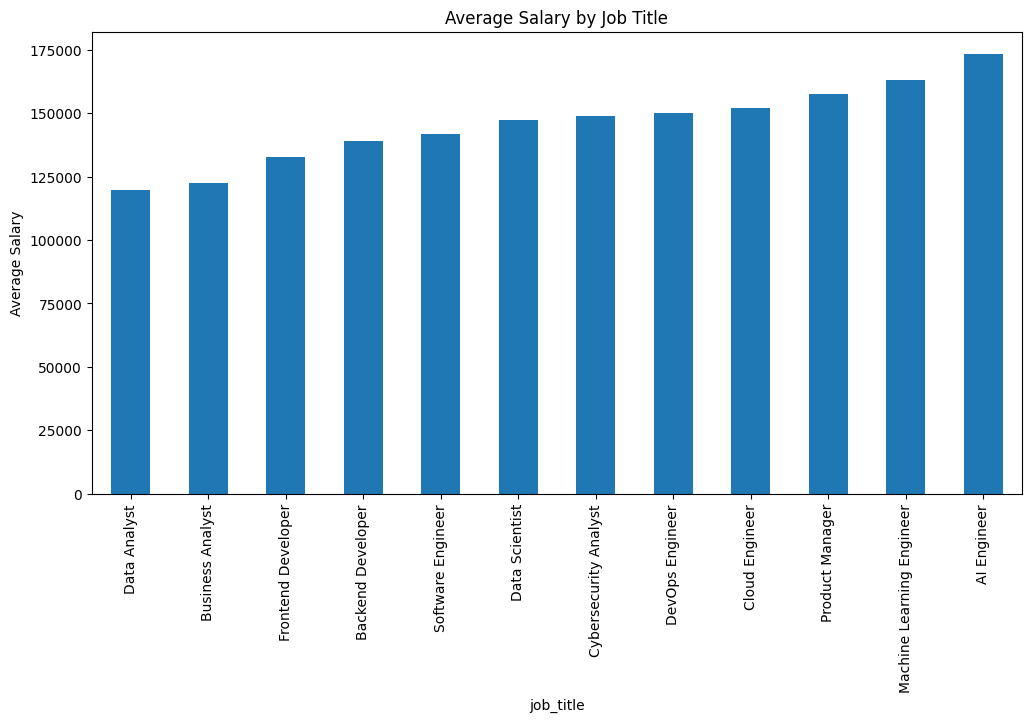

In [ ]:
plt.figure(figsize=(12,6))
df.groupby('job_title')['salary'].mean().sort_values().plot(kind='bar')
plt.title("Average Salary by Job Title")
plt.ylabel("Average Salary")
plt.show()

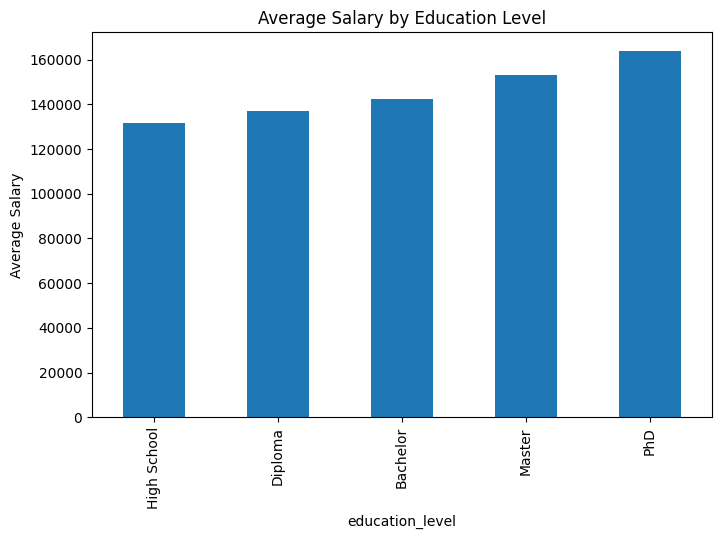

In [ ]:
plt.figure(figsize=(8,5))
df.groupby('education_level')['salary'].mean().sort_values().plot(kind='bar')
plt.title("Average Salary by Education Level")
plt.ylabel("Average Salary")
plt.show()

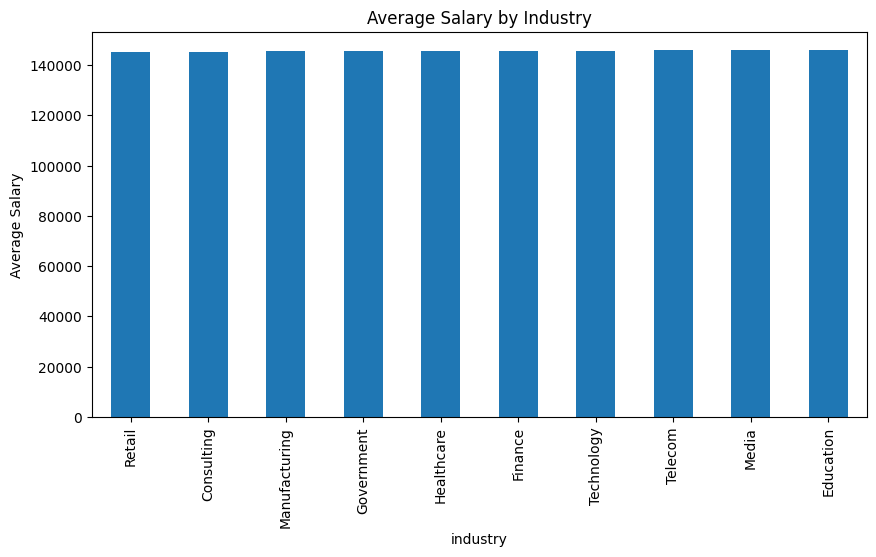

In [ ]:
plt.figure(figsize=(10,5))
df.groupby('industry')['salary'].mean().sort_values().plot(kind='bar')
plt.title("Average Salary by Industry")
plt.ylabel("Average Salary")
plt.show()

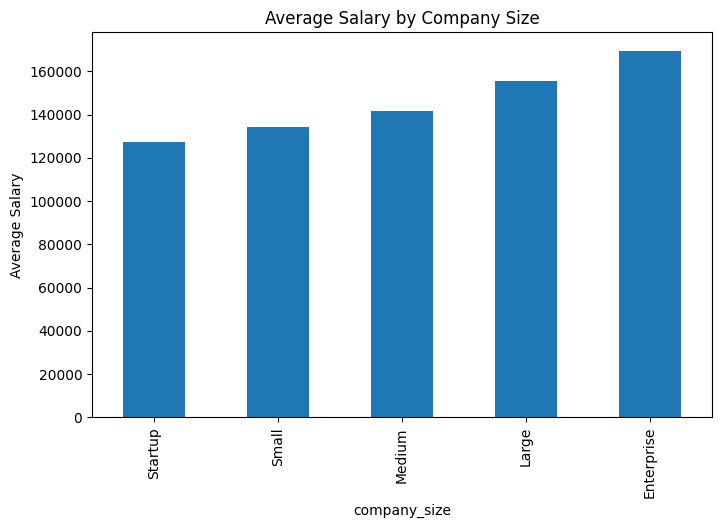

In [ ]:
plt.figure(figsize=(8,5))
df.groupby('company_size')['salary'].mean().sort_values().plot(kind='bar')
plt.title("Average Salary by Company Size")
plt.ylabel("Average Salary")
plt.show()

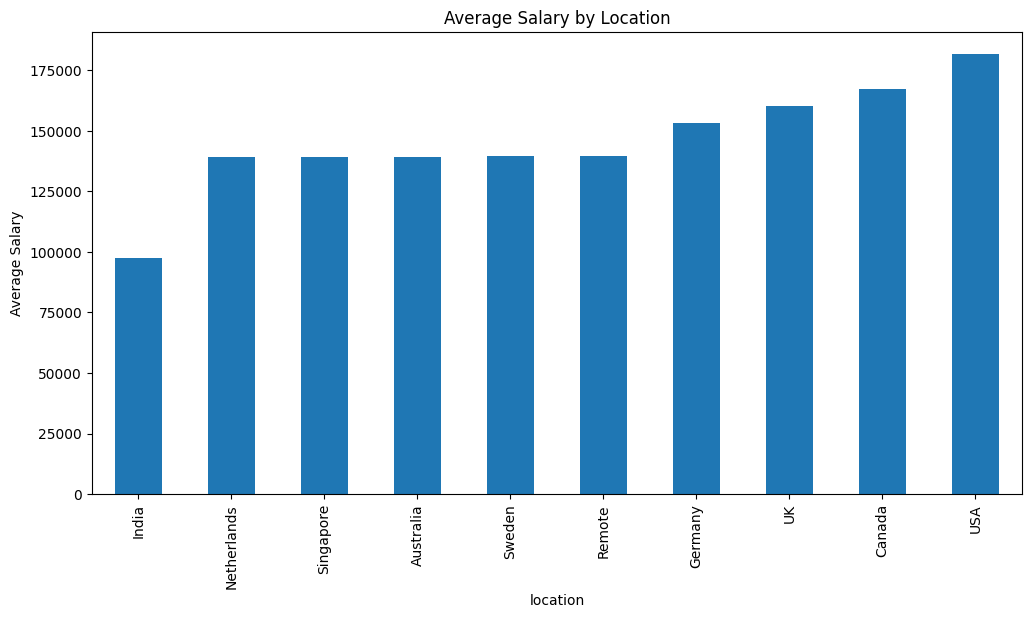

In [ ]:
plt.figure(figsize=(12,6))
df.groupby('location')['salary'].mean().sort_values().plot(kind='bar')
plt.title("Average Salary by Location")
plt.ylabel("Average Salary")
plt.show()

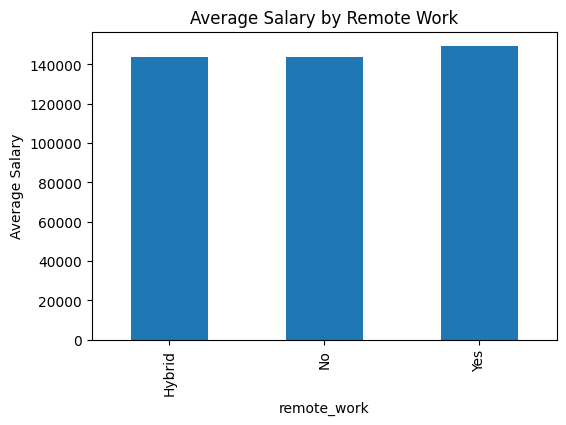

In [ ]:
plt.figure(figsize=(6,4))
df.groupby('remote_work')['salary'].mean().plot(kind='bar')
plt.title("Average Salary by Remote Work")
plt.ylabel("Average Salary")
plt.show()

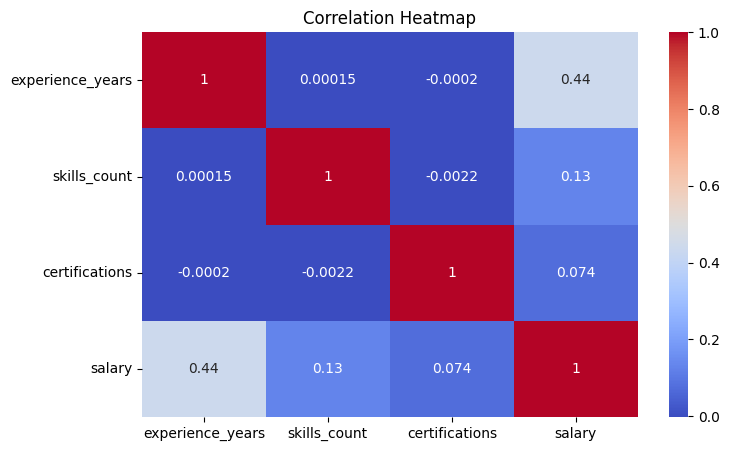

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['experience_years', 'skills_count', 'certifications', 'salary']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

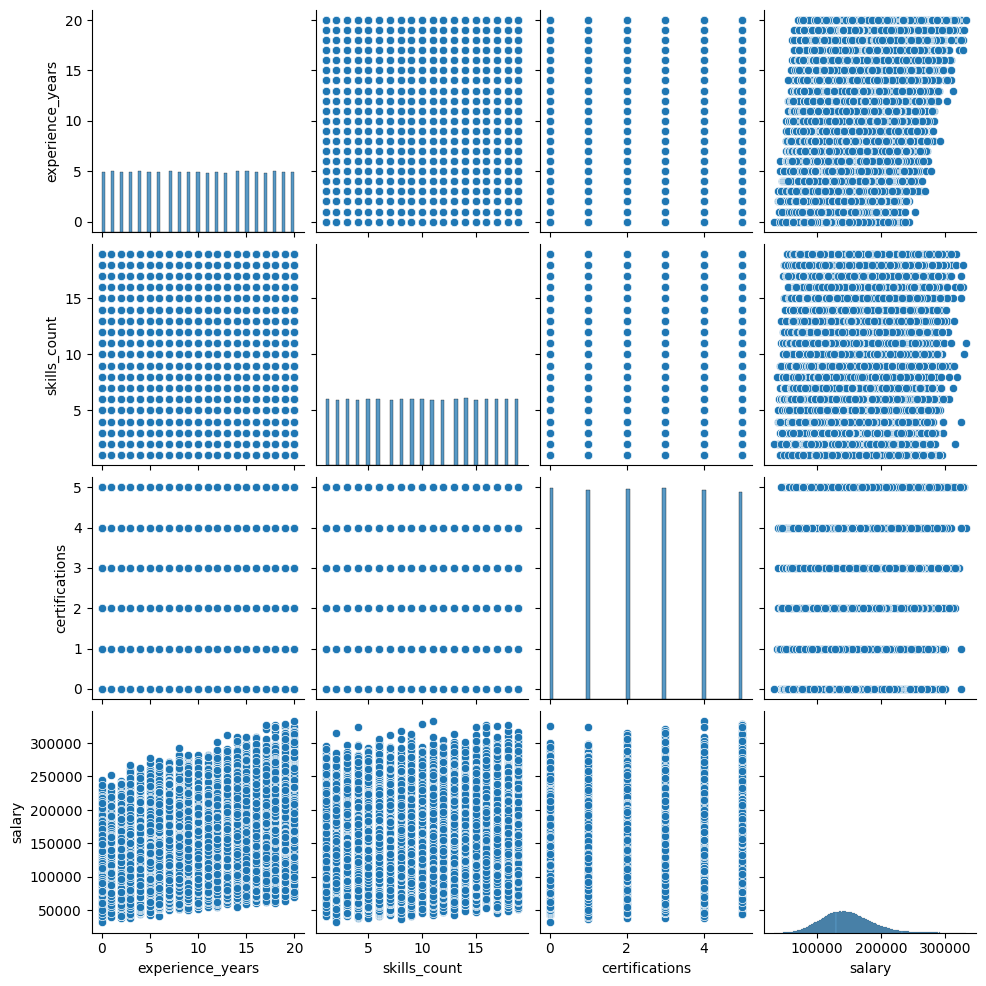

In [ ]:
sns.pairplot(df[['experience_years', 'skills_count', 'certifications', 'salary']])
plt.show()

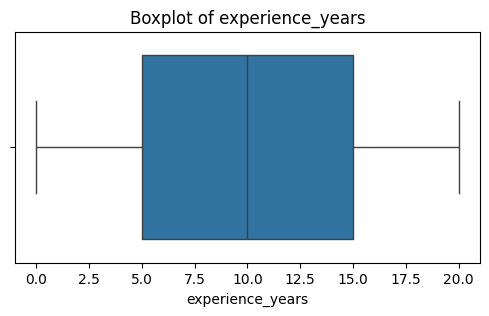

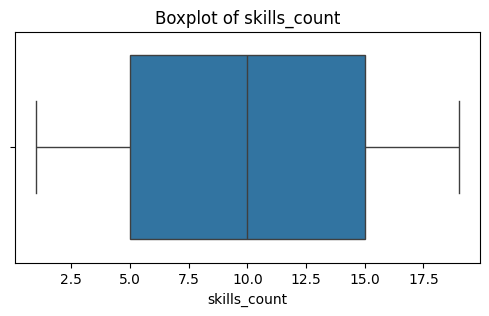

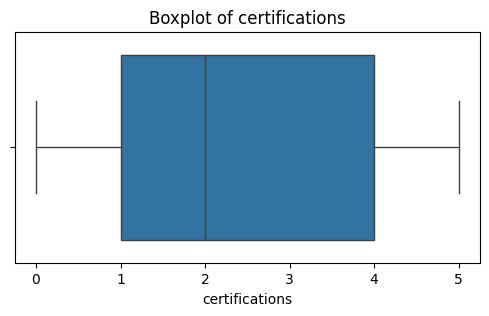

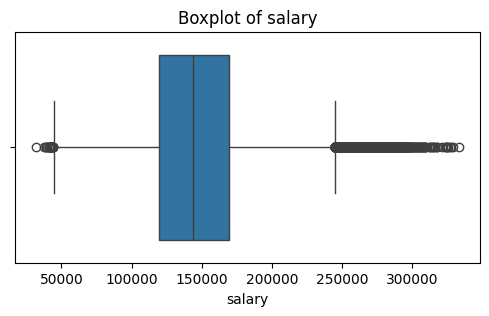

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['experience_years', 'skills_count', 'certifications', 'salary']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
for col in num_cols:
    print(f"{col} skewness: {df[col].skew()}")

experience_years skewness: -0.0009517323628733443
skills_count skewness: 0.0003020025100380292
certifications skewness: 0.003999892424639015
salary skewness: 0.3794009747285935


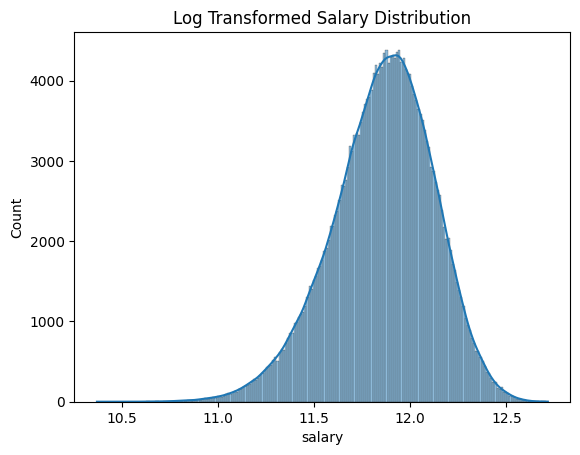

In [ ]:
sns.histplot(np.log1p(df['salary']), kde=True)
plt.title("Log Transformed Salary Distribution")
plt.show()

In [ ]:
X = df.drop("salary", axis=1)
X.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work',
       'certifications'],
      dtype='object')

In [ ]:
y = df[["salary"]]

In [ ]:
y

,salary
0,109413
1,93764
2,148123
3,189123
4,165069
...,...
249995,127791
249996,154593
249997,75988
249998,90467


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(200000, 9)
(200000, 1)
(50000, 9)
(50000, 1)


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 17.2+ MB


In [ ]:
cat_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
num_cols = ['experience_years', 'skills_count', 'certifications']

Scaled

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

In [ ]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', KNeighborsRegressor())])

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
y_train_pred = pipe.predict(X_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 10289.947844
Test MSE : 175993117.59552082
Test RMSE : 13266.239768507157
Test R2 Score : 0.8733738236550235
Train MAE : 8605.706031
Train MSE : 123654713.05702941
Train RMSE : 11120.01407629637
Train R2 Score : 0.9117836272693389


In [ ]:
from sklearn.pipeline import Pipeline
pipe1 = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", LinearRegression())
])

In [ ]:
pipe1.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', LinearRegression())])

In [ ]:
y_pred = pipe1.predict(X_test)

In [ ]:
y_train_pred = pipe1.predict(X_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 5436.096958649477
Test MSE : 50773076.89164505
Test RMSE : 7125.522920575377
Test R2 Score : 0.9634690226760201
Train MAE : 5470.9606765990375
Train MSE : 51359482.661201954
Train RMSE : 7166.553052981744
Train R2 Score : 0.9633596880079699


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
pipe2 = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", Lasso())
])

In [ ]:
#from sklearn.svm import SVR
#from sklearn.pipeline import Pipeline
#pipe2 = Pipeline([
#    ("preprocessing", scaled_preprocessor),
#    ("model", SVR())
#])

In [ ]:
pipe2.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', Lasso())])

In [ ]:
y_pred = pipe2.predict(X_test)

In [ ]:
y_train_pred = pipe2.predict(X_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 5435.7757312798885
Test MSE : 50771228.312229306
Test RMSE : 7125.393204043501
Test R2 Score : 0.963470352719753
Train MAE : 5470.816346909625
Train MSE : 51359848.772984475
Train RMSE : 7166.578596023662
Train R2 Score : 0.9633594268205661


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
pipe3 = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", Ridge())
])

In [ ]:
pipe3.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', Ridge())])

In [ ]:
y_pred = pipe3.predict(X_test)

In [ ]:
y_train_pred = pipe3.predict(X_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 5436.006836160271
Test MSE : 50772652.45944333
Test RMSE : 7125.493137983036
Test R2 Score : 0.9634693280528869
Train MAE : 5470.915614009453
Train MSE : 51359510.63109598
Train RMSE : 7166.555004400369
Train R2 Score : 0.9633596680539986


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
pipe4 = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", SVR())
])

In [ ]:
pipe4.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', StandardScaler(),
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', SVR())])

In [ ]:
y_pred = pipe4.predict(X_test)

In [ ]:
y_train_pred = pipe4.predict(X_train)

In [ ]:
# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 28205.492661064494
Test MSE : 1268873947.437517
Test RMSE : 35621.25696038135
Test R2 Score : 0.08705148006390728
Train MAE : 28292.05284784935
Train MSE : 1279108150.2253833
Train RMSE : 35764.62148863571
Train R2 Score : 0.08747286250975406


Not Scaled

In [ ]:
non_scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
pipe5 = Pipeline([
    ("preprocessing", non_scaled_preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [ ]:
pipe5.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', 'passthrough',
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [ ]:
y_pred = pipe5.predict(X_test)

In [ ]:
y_train_pred = pipe5.predict(X_train)

In [ ]:
# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 7275.75388
Test MSE : 85182497.45378
Test RMSE : 9229.436464583307
Test R2 Score : 0.9387116150253232
Train MAE : 2.256135
Train MSE : 9659.1420825
Train RMSE : 98.28093448121055
Train R2 Score : 0.9999931090820791


In [ ]:
from sklearn.pipeline import Pipeline
pipe6 = Pipeline([
    ("preprocessing", non_scaled_preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

In [ ]:
pipe6.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', 'passthrough',
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
y_pred = pipe6.predict(X_test)

In [ ]:
y_train_pred = pipe6.predict(X_train)

In [ ]:
# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 5019.38038021
Test MSE : 39992754.47684604
Test RMSE : 6323.982485494883
Test R2 Score : 0.9712254112541766
Train MAE : 1864.0565905020835
Train MSE : 5617272.523061416
Train RMSE : 2370.0785900601304
Train R2 Score : 0.9959925877924641


In [ ]:
from sklearn.pipeline import Pipeline
pipe7 = Pipeline([
    ("preprocessing", non_scaled_preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [ ]:
pipe7.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', 'passthrough',
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [ ]:
y_pred = pipe7.predict(X_test)

In [ ]:
y_train_pred = pipe7.predict(X_train)

In [ ]:
# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 6595.432406117542
Test MSE : 70428898.369426
Test RMSE : 8392.192703306211
Test R2 Score : 0.9493267564859801
Train MAE : 6579.828677398709
Train MSE : 70248693.44609039
Train RMSE : 8381.44936428601
Train R2 Score : 0.9498839569339814


In [ ]:
from sklearn.pipeline import Pipeline
pipe8 = Pipeline([
    ("preprocessing", non_scaled_preprocessor),
    ("model", XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1))
])

In [ ]:
pipe8.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job_title',
                                                   'education_level',
                                                   'industry', 'company_size',
                                                   'location', 'remote_work']),
                                                 ('num', 'passthrough',
                                                  ['experience_years',
                                                   'skills_count',
                                                   'certifications'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_b...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred = pipe8.predict(X_test)

In [ ]:
y_train_pred = pipe8.predict(X_train)

In [ ]:
# Test metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Test MAE :", mae)
print("Test MSE :", mse)
print("Test RMSE :", rmse)
print("Test R2 Score :", r2)

print("Train MAE :", train_mae)
print("Train MSE :", train_mse)
print("Train RMSE :", train_rmse)
print("Train R2 Score :", train_r2)

Test MAE : 4352.392578125
Test MSE : 29853310.0
Test RMSE : 5463.818261984928
Test R2 Score : 0.9785206913948059
Train MAE : 4269.765625
Train MSE : 28693502.0
Train RMSE : 5356.6315908413935
Train R2 Score : 0.9795297980308533


In [136]:
import pickle
with open("SalaryPrediction.pkl_XGBRegressor", "wb") as file:
    pickle.dump(pipe8, file)
print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl
